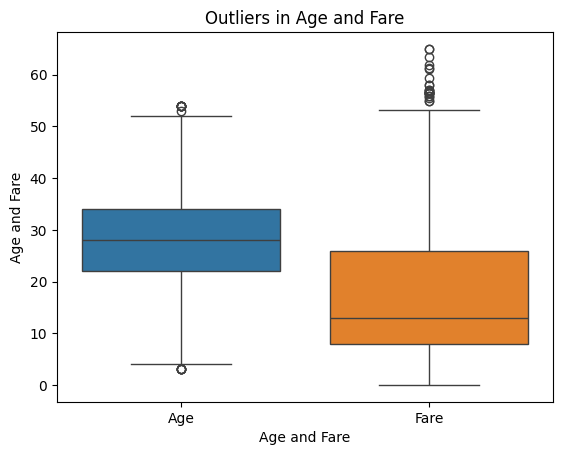

In [16]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. load data
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

# 2. drop unnecessary columns
df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True)

# 3. fill missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 5. Remove outliers
Q1 = df[['Age', 'Fare']].quantile(0.25)
Q3 = df[['Age', 'Fare']].quantile(0.75)
IQR = Q3 - Q1

df = df[(df[['Age', 'Fare']] > Q1[['Age', 'Fare']] - 1.5 * IQR[['Age', 'Fare']]) & (df[['Age', 'Fare']] < Q3[['Age', 'Fare']] + 1.5 * IQR[['Age', 'Fare']])]

# check distribution

# check outliers
sns.boxplot(df[['Age', 'Fare']])
plt.title('Outliers in Age and Fare')
plt.xlabel('Age and Fare')
plt.ylabel('Age and Fare')
plt.show()

# check skewness
# print(df['Survived'].skew())

# check correlation
# sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
# plt.show()


